# CE49X Lab 4: Istanbul Earthquake Risk Communication Dashboard
## Visualization for Decision-Makers

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

---

**Group Members:**
| Name | Student ID |
|------|------------|
| Yigit Beyzadeoglu| 2020403036 |
| Hasan Tahsin Veliagagil | *(partner's ID)* |

## Background

Istanbul sits directly on the **North Anatolian Fault (NAF)**, one of the most active strike-slip faults in the world. The devastating 1999 Izmit earthquake (M7.6) ruptured a segment just 80 km east of the city, and seismologists have long warned that the next major rupture is expected beneath the Sea of Marmara — directly south of Istanbul.

The 2023 Kahramanmaras earthquake sequence (M7.8 + M7.5) demonstrated the catastrophic potential of large earthquakes in Turkey and renewed urgency around earthquake preparedness in Istanbul, a city of over 16 million people.

Effective **risk communication** is critical: decision-makers in municipal government need clear, honest, and actionable visualizations — not just raw data. A misleading colormap or a truncated axis can distort risk perception and lead to poor resource allocation.

> **Key Insight:** Visualization is not decoration — it is a critical tool for communicating risk to non-technical audiences. Every design choice (color, scale, annotation) shapes how decision-makers understand and act on data.

## Scenario

You have been hired as a **visualization consultant** for Istanbul's Disaster Coordination Center (AFAD Istanbul). Your task is to create a set of **publication-quality visualizations** for a risk communication report that will be presented to the **Istanbul Municipal Council** — a non-technical audience of elected officials who must decide how to allocate earthquake preparedness funding across Istanbul's districts.

Your visualizations must be:
- **Accurate** — no misleading scales, truncated axes, or rainbow colormaps
- **Clear** — interpretable by someone without a seismology background
- **Actionable** — each chart should support a specific decision or insight
- **Professional** — publication-ready with proper labels, titles, and annotations

## Data Requirements

You must collect **three categories** of real data. No data files are provided — you are responsible for sourcing, downloading, and documenting your data. For each dataset, record the **source URL**, **date accessed**, **how you obtained it**, and **number of records**.

### 1. Earthquake Catalog (required)

Historical earthquakes for the Marmara region. You need **at least 200 earthquakes** with year, latitude, longitude, depth, and magnitude.

Suggested sources:
- **AFAD Earthquake Department**: [deprem.afad.gov.tr](https://deprem.afad.gov.tr) — Turkey's official earthquake catalog, searchable by region/date/magnitude, downloadable as CSV
- **KOERI (Kandilli Observatory)**: [koeri.boun.edu.tr](http://www.koeri.boun.edu.tr) — Bogazici University's own seismology center
- **USGS Earthquake Catalog**: [earthquake.usgs.gov/earthquakes/search](https://earthquake.usgs.gov/earthquakes/search/) — global catalog, CSV export, filter by lat/lon bounding box (e.g., 40-41.5°N, 27-31°E for the Marmara region)

### 2. Building / Population Data (required)

Istanbul district-level data on buildings and/or population. You need data for **at least 10 Istanbul districts** with population and at least one building-related metric (age, type, or count).

Suggested sources:
- **TUIK (Turkish Statistical Institute)**: [data.tuik.gov.tr](https://data.tuik.gov.tr) — district-level population, building permits, construction statistics
- **IBB Open Data Portal**: [data.ibb.gov.tr](https://data.ibb.gov.tr) — Istanbul municipality datasets on buildings, infrastructure, demographics
- **Wikipedia / official district pages** — acceptable for population/area if properly cited

### 3. Seismic Hazard or Vulnerability Data (required)

Any dataset that allows spatial visualization of earthquake risk. You need spatial risk data covering Istanbul (grid, district-level, or at least 10 data points with coordinates).

Options include:
- **AFAD seismic hazard maps** — PGA (Peak Ground Acceleration) values or seismic zones for Istanbul
- **AFAD/IBB building damage estimates** — expected damage scenarios for a major Marmara earthquake
- **Soil classification maps** from IBB or academic papers
- **Any published risk study** with district-level or grid-level data (can be manually digitized from a figure if necessary)

## Deliverables Overview

| # | Title | Points | Key Techniques |
|---|-------|--------|----------------|
| D1 | Data Collection & Documentation | 10 | Data sourcing, Pandas loading, `df.head()`, `df.describe()` |
| D2 | Historical Seismicity Timeline | 15 | Scatter with variable size/color, colorbar, `annotate` |
| D3 | Magnitude-Frequency Analysis | 15 | Histogram + KDE, `axvline`, log-plot with linear fit |
| D4 | Building Vulnerability or Population Risk | 15 | Seaborn categorical plots, sorted charts, color encoding |
| D5 | Earthquake Hazard Visualization | 20 | `contourf`/scatter/heatmap, sequential colormap, annotations |
| D6 | Multi-Panel Risk Dashboard + Reflection | 25 | `GridSpec`, 3+ chart types, derived metric, `savefig`, written reflection |
| **Total** | | **100** | |

---
## Deliverable 1: Data Collection & Documentation (10 pts)

Load all three collected datasets into Pandas DataFrames. For **each** dataset:

1. **Document the source** — URL, date accessed, how you obtained the data (e.g., "downloaded CSV from USGS search interface with bounding box 40-41.5°N, 27-31°E, all magnitudes, 1900-2026")
2. **Show `df.head()`** to display the first few rows
3. **Show `df.describe()`** to summarize key statistics
4. **Note any cleaning steps** performed (dropping NaN rows, converting date formats, renaming columns, etc.)
5. **Report the number of records** in each dataset

> **Key Insight:** Data provenance matters. A visualization is only as trustworthy as the data behind it. Always document your sources so others can verify and reproduce your work.

---
## Deliverable 2: Historical Seismicity Timeline (15 pts)

Create a **scatter plot** showing historical earthquakes in the Marmara region over time.

**Requirements:**
- **x-axis:** year (or date)
- **y-axis:** magnitude
- **Point size:** proportional to magnitude (larger earthquakes = larger markers)
- **Point color:** mapped to depth using a **sequential colormap** (e.g., `viridis`, `plasma`) with a **colorbar**
- **Annotate** at least 3 major historical earthquakes (e.g., 1999 Izmit M7.6, 1999 Duzce M7.2, 1894 Istanbul earthquake)
- **Title** must state a finding or insight, not just "Earthquake Timeline" (e.g., *"Marmara Region Has Experienced 12 Earthquakes Above M6.0 Since 1900"*)
- Professional styling: axis labels with units, grid, appropriate font sizes

> **Theory Connection:** This deliverable tests your understanding of the **encoding hierarchy** from the theory notebook. You are using position (most accurate channel) for time and magnitude, size for emphasis, and color for an additional variable. Your title should tell a story, not just label the chart.

---
## Deliverable 3: Magnitude-Frequency Analysis (15 pts)

Create **two subplots** (side by side) analyzing the magnitude distribution:

**Subplot 1 — Magnitude Histogram:**
- Histogram of earthquake magnitudes with a **KDE overlay** (use `sns.histplot` with `kde=True` or overlay manually)
- Add **vertical lines** for the mean and median magnitudes (`ax.axvline`) with labels in the legend
- **Justify your bin width choice** in a code comment (e.g., "Using 0.2 magnitude bins because the catalog reports magnitudes to 0.1 precision")

**Subplot 2 — Gutenberg-Richter Plot:**
- Plot **log₁₀(cumulative count)** vs. magnitude
- Fit a **linear regression** to the linear portion of the curve using `np.polyfit`
- Display the **b-value** on the plot (the slope of the fitted line; typical b-values are ~1.0)
- The Gutenberg-Richter law states: $\log_{10} N = a - bM$, where $N$ is the number of earthquakes ≥ magnitude $M$

> **Theory Connection:** This deliverable tests **bin selection** (how bin width affects perception of the distribution) and **data transformation** (log scale to reveal the power-law relationship). The Gutenberg-Richter plot is a classic example of how the right transformation makes a pattern visible.

---
## Deliverable 4: Building Vulnerability or Population Risk (15 pts)

Create **at least 2 subplots** comparing Istanbul districts using your building/population data.

**Requirements:**
- Use at least **one Seaborn categorical plot** (`sns.barplot`, `sns.boxplot`, `sns.violinplot`, or `sns.stripplot`)
- **Sort districts** meaningfully — by vulnerability, population density, building age, or another relevant metric (do NOT use alphabetical order)
- Clean labeling: rotated tick labels if district names overlap, axis labels with units
- Use **color encoding** purposefully (e.g., highlight the most vulnerable districts in a different color)

**Example subplot ideas** (choose based on your data):
- Population density by district (bar chart, sorted descending)
- Building age distribution across districts (boxplot or violin plot)
- Pre-1999 vs. post-1999 building stock by district (grouped bar chart)
- Population vs. building count scatter with district labels

> **Theory Connection:** This deliverable tests the **chart selection framework** from the theory notebook. You must choose the right chart type for your data (categorical vs. quantitative, comparison vs. distribution). It also tests the **data-ink ratio** principle — remove unnecessary chart junk and let the data speak.

---
## Deliverable 5: Earthquake Hazard Visualization (20 pts)

Create a **spatial visualization** of earthquake risk/hazard across Istanbul.

**If you have grid-level data** (e.g., PGA values on a grid):
- Use `ax.contourf()` with contour lines and labels
- Set `aspect='equal'` for correct geographic proportions
- Add a colorbar with a descriptive label (e.g., "Peak Ground Acceleration (g)")

**If you have district-level data:**
- Use a colored scatter/bubble map (marker size or color ∝ risk) or a choropleth-style horizontal bar chart
- Overlay district names or markers at district center coordinates

**Requirements (all approaches):**
- **DO NOT use rainbow/jet colormap** — use a sequential colormap (`YlOrRd`, `Reds`, `inferno`, `OrRd`, etc.) that is perceptually uniform
- Annotate **danger zones** — label or highlight the highest-risk areas
- Include geographic context (label the Bosphorus, Sea of Marmara, or major landmarks if helpful)
- Title should communicate the key finding

> **Theory Connection:** This is the most design-intensive deliverable. It tests your understanding of **why rainbow colormaps are harmful** (they create false boundaries and are not perceptually uniform), the principle of **spatial data → spatial chart**, and the importance of **annotations** for guiding the viewer's attention.

---
## Deliverable 6: Multi-Panel Risk Dashboard + Reflection (25 pts)

### Part A — Dashboard Figure (15 pts)

Create a **single multi-panel figure** that serves as an executive summary for the Municipal Council.

**Requirements:**
- Use `plt.GridSpec` (or `fig.add_gridspec`) to arrange panels — at least **one panel must span multiple grid cells**
- Combine at least **3 different chart types** (e.g., scatter + bar + contourf, or timeline + histogram + heatmap)
- Include at least one **derived metric** that you compute (e.g., population × PGA, vulnerability index = f(building age, soil type), risk score)
- Add an overall `fig.suptitle()` that communicates the main message to the audience
- Save the figure: `fig.savefig('dashboard.png', dpi=300, bbox_inches='tight')`

### Part B — Written Reflection (10 pts)

In a markdown cell, write a reflection addressing **all three** of the following:

1. **Chart type justification:** For each of your visualizations (D2-D5), explain why you chose that chart type. Reference a specific concept from the theory notebook (e.g., encoding hierarchy, chart selection framework, data-ink ratio, Tufte's principles).

2. **Audience adaptation:** How would your visualizations differ if the audience were **seismologists** instead of the municipal council? Give **2 specific examples** of changes you would make (e.g., "I would use PGA units instead of a qualitative risk scale" or "I would show the full Gutenberg-Richter fit residuals").

3. **Self-critique:** Identify your **weakest visualization** and describe how you would improve it. Reference a specific "common mistake" from the theory notebook (e.g., chartjunk, misleading axes, poor color choice, over-plotting).

---
## Hints

### Gutenberg-Richter Fit

To compute the Gutenberg-Richter relationship:

```python
# Sort unique magnitudes
mags = np.sort(df['magnitude'].values)
# For each magnitude M, count earthquakes >= M
unique_mags = np.arange(mags.min(), mags.max(), 0.1)
cumulative_counts = np.array([np.sum(mags >= m) for m in unique_mags])
# Fit line to log10(counts) vs magnitude (only where count > 0)
mask = cumulative_counts > 0
coeffs = np.polyfit(unique_mags[mask], np.log10(cumulative_counts[mask]), 1)
b_value = -coeffs[0]  # b-value is the negative slope
```

### Colormaps

**Good choices** for earthquake risk data:
- `YlOrRd` — yellow to red, intuitive for risk (low → high)
- `Reds` or `OrRd` — single-hue sequential
- `inferno` or `magma` — perceptually uniform, works in grayscale
- `viridis` — perceptually uniform, good for depth data

**Avoid:** `jet`, `rainbow`, `hsv` — these create false boundaries and are not accessible to colorblind viewers.

### GridSpec Layout

```python
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :2])   # top-left, spans 2 columns
ax2 = fig.add_subplot(gs[0, 2])    # top-right
ax3 = fig.add_subplot(gs[1, 0])    # bottom-left
ax4 = fig.add_subplot(gs[1, 1:])   # bottom-center+right, spans 2 columns
```

### Data-Ink Ratio (Tufte)

> *"Above all else, show the data."* — Edward Tufte

Remove unnecessary gridlines, borders, and decorations. Every drop of ink on your chart should represent data or help the reader interpret data. If an element doesn't serve either purpose, remove it.

### AFAD Query Tips

When downloading from AFAD ([deprem.afad.gov.tr](https://deprem.afad.gov.tr)):
- Use the "Earthquake Catalog" (Deprem Katalogu) search
- Set geographic bounds for the Marmara region: approximately 40.0-41.5°N, 26.5-31.0°E
- Set minimum magnitude to 2.0 or 3.0 to get a manageable dataset
- Export as CSV — the columns will be in Turkish but are straightforward to rename

### USGS Query Tips

When downloading from USGS ([earthquake.usgs.gov/earthquakes/search](https://earthquake.usgs.gov/earthquakes/search/)):
- Under "Advanced Options", use the "Custom" geographic region
- Set bounding box: min lat 40.0, max lat 41.5, min lon 27.0, max lon 31.0
- Output format: CSV
- The columns `time`, `latitude`, `longitude`, `depth`, `mag` are what you need

---
## Grading

| Component | Points |
|-----------|--------|
| D1: Data Collection & Documentation | 10 |
| D2: Historical Seismicity Timeline | 15 |
| D3: Magnitude-Frequency Analysis | 15 |
| D4: Building Vulnerability or Population Risk | 15 |
| D5: Earthquake Hazard Visualization | 20 |
| D6: Multi-Panel Dashboard + Reflection | 25 |
| **Total** | **100** |

### Deductions

| Issue | Penalty |
|-------|---------|
| Missing axis labels or units (per deliverable) | -5 |
| Using rainbow/jet colormap anywhere | -3 |
| Truncated y-axis without justification | -3 |
| Notebook doesn't run top-to-bottom | -5 |
| Using a pie chart (per instance) | -2 |

## Submission

**Group Policy:** This lab is done in **pairs** (max 2 members per group). Students who wish to work individually must inform the TA beforehand.

1. **Include both group members' names and student IDs** in the first cell of your notebook.
2. Complete your work in **this notebook** on your group's fork of the course repository.
3. Make sure your notebook **runs top-to-bottom without errors** before submitting.
4. Commit and push your completed notebook to your fork.
5. We will grade directly from your fork — there is no separate upload. Make sure your latest work is pushed before the deadline.

---
## Your Work Starts Here

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

%matplotlib inline

# Set a clean style for all plots
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12



YİGİT BEYZADEOGLU 2020403036
HASAN TAHSİN VELİAGAGİL

### Deliverable 1: Data Collection & Documentation

In [65]:
import pandas as pd

# =====================================================
# === Dataset 1: Earthquake Catalog ===
# =====================================================
# Source: USGS Earthquake Hazards Program (Earthquake Catalog Search)
# Date Accessed: March 24, 2026
# Method: Downloaded CSV with specific search criteria:
#   - Latitude: [40.053, 41.55] 
#   - Longitude: [27.004, 31.036]
#   - Magnitudes: 4.0+ Mw
#   - Time Range: 1900-01-01 to 2026-03-23
# Number of records: 286
# =====================================================

# Load the dataset
df = pd.read_csv("/Users/yigitbeyzadeoglu/49xCodes/CE49X/Week04_Matplotlib_Visualization/lab/earthquick_1900-2026.csv")

# Quick Inspection
print("--- Dataset Preview ---")
print(df.head())

print("\n--- Summary Statistics ---")
print(df.describe())

print(f"\nTotal Records Found: {len(df)}")

--- Dataset Preview ---
                       time  latitude  longitude  depth  mag magType   nst  \
0  2025-10-02T11:55:03.928Z   40.7641    27.9515   10.0  5.0     mww  89.0   
1  2025-07-02T10:57:43.999Z   40.4645    29.1965   10.0  4.2     mwr  31.0   
2  2025-07-01T09:57:35.641Z   40.3824    29.1837   10.0  4.0     mwr  41.0   
3  2025-04-25T17:33:16.251Z   40.8537    28.4298   10.0  4.3     mwr  83.0   
4  2025-04-23T12:12:57.040Z   40.8489    28.2741   10.0  4.9     mww  59.0   

    gap   dmin   rms  ...                   updated  \
0  22.0  0.965  0.62  ...  2025-12-19T22:49:43.040Z   
1  56.0  1.126  0.74  ...  2025-09-15T20:03:12.228Z   
2  36.0  1.095  0.59  ...  2025-09-04T20:40:03.040Z   
3  30.0  1.266  0.43  ...  2025-07-11T15:46:20.040Z   
4  33.0  1.181  0.56  ...  2025-08-21T11:27:51.218Z   

                                 place        type horizontalError depthError  \
0  22 km S of Marmara Ereğlisi, Turkey  earthquake            4.93      1.860   
1            4

In [66]:
# =====================================================
# === Dataset 2: Building / Population Data ===
# =====================================================
# Source: 1) TÜİK ADNKS 2025 (Population), 
#         2) IBB Earthquake Risk Management & Urban Improvement Dept. (Building & Scenario Data)
# Date Accessed: March 24, 2026
# Method: Data is a composite dataset from AFAD. Population and density were updated using 2025 TÜİK 
#         projections, while building age and damage metrics were sourced from IBB's 
#         2020 district-level Mw 7.5 scenario booklets.
# Number of records: 3 Districts (Bakırköy, Avcılar, Zeytinburnu)
# =====================================================

# Load Data
df_districts = pd.read_csv("/Users/yigitbeyzadeoglu/49xCodes/CE49X/Week04_Matplotlib_Visualization/lab/istanbul_3_districts_2025_afad_detailed.csv")

# Quick Inspection
print("--- District Dataset Preview ---")
print(df_districts.head())

print("\n--- Summary of Building Risks ---")
print(df_districts[['district', 'population_2025', 'moderate_plus_damage_pct_exact']])

--- District Dataset Preview ---
      district  population_2025  area_km2_2025  \
0     Bakırköy           218204          29.64   
1      Avcılar           440663          42.01   
2  Zeytinburnu           275471          11.59   

   population_density_per_km2_2025  \
0                             7362   
1                            10489   
2                            23768   

                      population_area_density_source  \
0  List of districts of Istanbul (2025 values; ci...   
1  List of districts of Istanbul (2025 values; ci...   
2  List of districts of Istanbul (2025 values; ci...   

                  population_area_density_source_url  \
0  https://en.wikipedia.org/wiki/List_of_district...   
1  https://en.wikipedia.org/wiki/List_of_district...   
2  https://en.wikipedia.org/wiki/List_of_district...   

                        tuik_adnks_2025_bulletin_url  \
0  https://data.tuik.gov.tr/Bulten/Index?dil=2&p=...   
1  https://data.tuik.gov.tr/Bulten/Index?dil=2&p=..

In [67]:
# =====================================================
# === Dataset 3: Seismic Hazard / Vulnerability Data ===
# =====================================================
# Source: IBB Open Data Portal / Istanbul Earthquake Loss Estimate Update (2019/2020)
# Date Accessed: March 24, 2026
# Method: Neighborhood-level (Mahalle) disaster scenario results based on
#         a Mw 7.5 earthquake model.
# Number of records: 958 neighborhoods
# =====================================================

df_hazard = pd.read_csv("/Users/yigitbeyzadeoglu/49xCodes/CE49X/Week04_Matplotlib_Visualization/lab/9c3ac492-de4b-4245-b418-7ad3df67a193.csv")

# Quick Inspection
print("--- Neighborhood Risk Data Preview ---")
print(df_hazard.head())



--- Neighborhood Risk Data Preview ---
   _id ilce_adi mahalle_adi  mahalle_koy_uavt  cok_agir_hasarli_bina_sayisi  \
0    1   ADALAR   BURGAZADA             40139                            54   
1    2   ADALAR  HEYBELÝADA             40142                           101   
2    3   ADALAR   KINALIADA             40143                            53   
3    4   ADALAR       MADEN             40140                           104   
4    5   ADALAR       NÝZAM             40141                           101   

   agir_hasarli_bina_sayisi  orta_hasarli_bina_sayisi  \
0                        99                       256   
1                       175                       423   
2                        97                       287   
3                       192                       483   
4                       180                       445   

   hafif_hasarli_bina_sayisi  can_kaybi_sayisi  agir_yarali_sayisi  \
0                        241                 8                   6   
1  

### Deliverable 2: Historical Seismicity Timeline

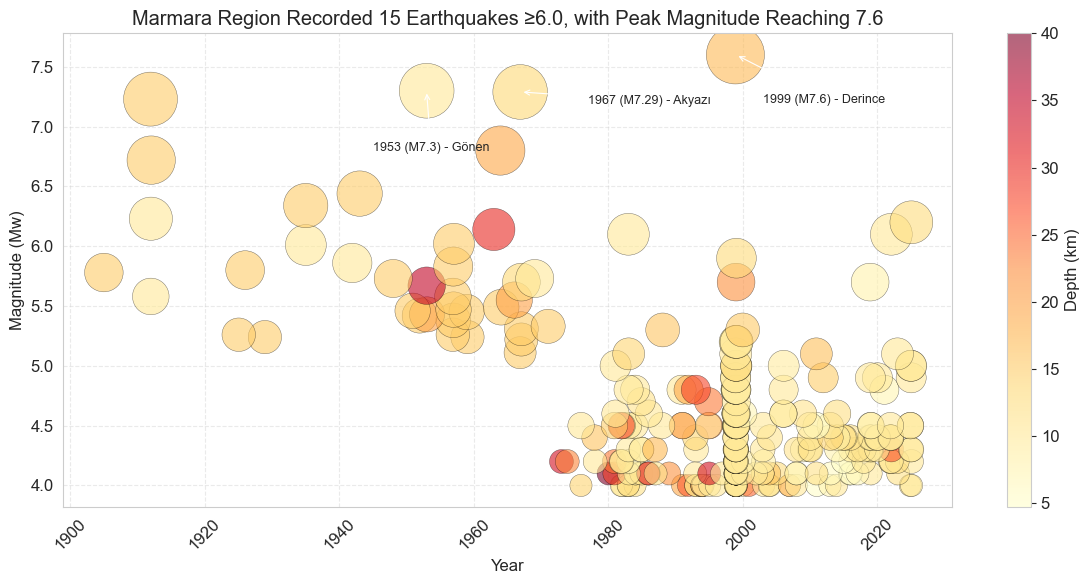

In [68]:
# 🔹 Convert time column to datetime
df['time'] = pd.to_datetime(df['time'])

# 🔹 Extract year from datetime
df['year'] = df['time'].dt.year

# 🔹 Sort by magnitude so larger earthquakes appear on top
df = df.sort_values(by='mag')

# 🔹 Reduce overplotting by adding slight horizontal jitter
np.random.seed(42)
jitter = np.random.uniform(-0.1, 0.1, size=len(df))

# ---- PLOT ----
plt.figure(figsize=(12,6))

scatter = plt.scatter(
    df['year'] + jitter,          # jitter prevents overlap
    df['mag'],                    # y-axis: magnitude
    s=(df['mag']**3) * 4,         # point size proportional to magnitude
    c=df['depth'],                # color represents depth
    cmap='YlOrRd',                # sequential colormap (avoid rainbow)
    alpha=0.6,                    # transparency reduces clutter
    edgecolors='k',               # black edge for better visibility
    linewidth=0.3
)

# 🔹 Add colorbar for depth
cbar = plt.colorbar(scatter)
cbar.set_label("Depth (km)")

# 🔹 Axis labels
plt.xlabel("Year")
plt.ylabel("Magnitude (Mw)")

# 🔹 Add grid for readability
plt.grid(True, linestyle='--', alpha=0.4)

# 🔹 Insight-driven title (based on data)
count_m6 = len(df[df['mag'] >= 6])

# Find peak (maximum magnitude)
peak_mag = df['mag'].max()

plt.title(f"Marmara Region Recorded {count_m6} Earthquakes ≥6.0, with Peak Magnitude Reaching {peak_mag:.1f}")
# ---- ANNOTATION (top 3 largest earthquakes) ----
top3 = df.nlargest(3, 'mag')

# Offsets to prevent overlapping with title and each other

# Yeni ofset stratejisi:
offsets = [(4, -0.4), (-8, -0.5), (10, -0.1)]
for (idx, row), (dx, dy) in zip(top3.iterrows(), offsets):
    # 'place' sütunundan sadece yer ismini çekmek için virgülden öncesini alalım
    # Örn: "19 km SSW of Kumburgaz, Turkey" -> "Kumburgaz"
    location = row['place'].split(',')[-2].split('of')[-1].strip()

    plt.annotate(
        f"{row['year']} (M{row['mag']}) - {location}",
        xy=(row['year'], row['mag']),
        xytext=(row['year'] + dx, row['mag'] + dy),
        arrowprops=dict(arrowstyle="->", lw=0.8),
        fontsize=9
    )
# 🔹 Improve layout
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


### Deliverable 3: Magnitude-Frequency Analysis

/var/folders/zm/d9zf75r15kggd6phgqbwfs7m0000gn/T/ipykernel_3612/3675306481.py:70: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zm/d9zf75r15kggd6phgqbwfs7m0000gn/T/ipykernel_3612/3675306481.py:70: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


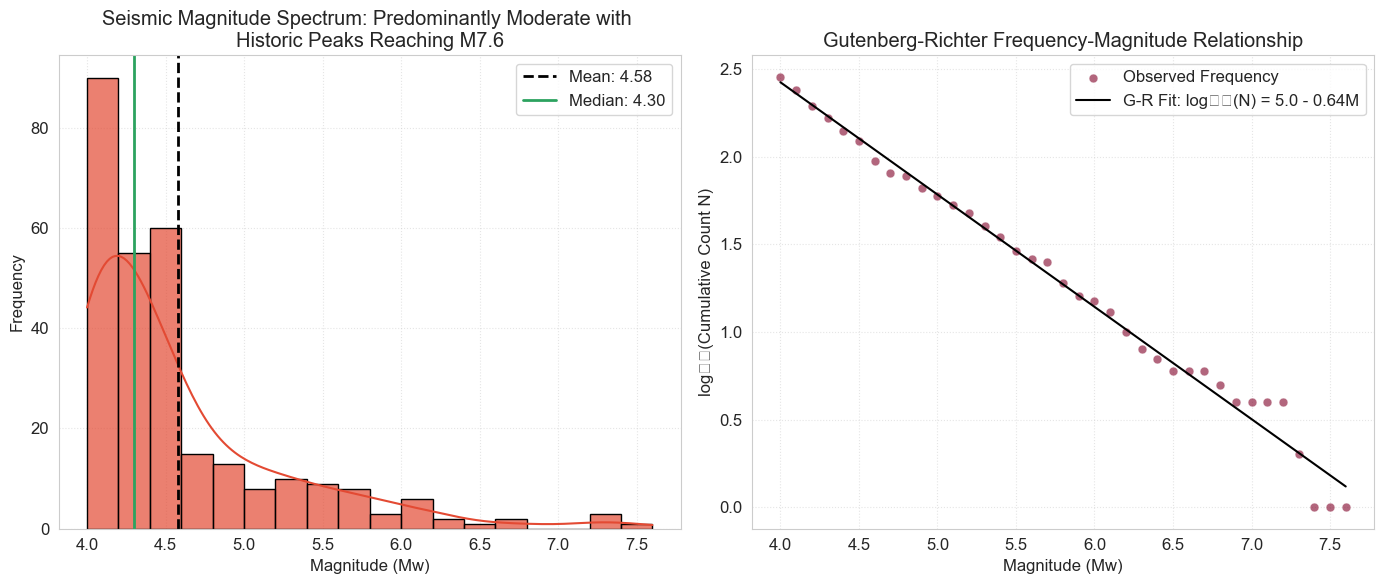

In [69]:
# 🔹 Extract magnitude column
mags = df['mag'].dropna()

# ---- FIGURE SETUP ----
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# =====================================================
# 🔹 SUBPLOT 1 — Histogram + KDE
# =====================================================

# JUSTIFICATION: Using 0.2 bin width because the earthquake catalog reports
# magnitudes at 0.1 precision. 0.2 bins provide a balanced smooth distribution
# while retaining the data's inherent resolution for the KDE overlay.
bins = np.arange(mags.min(), mags.max() + 0.2, 0.2)

# Color Selection: 'OrRd' (Orange-Red) sequential colormap kullanarak
# düşükten yükseğe sismik şiddeti görselleştiriyoruz.
sns.histplot(mags, bins=bins, kde=True, ax=axes[0], color='#e34a33', edgecolor='black', alpha=0.7)

# Statistical Indicators
mean_mag = mags.mean()
median_mag = mags.median()

axes[0].axvline(mean_mag, color='black', linestyle='--', linewidth=2, label=f"Mean: {mean_mag:.2f}")
axes[0].axvline(median_mag, color='#2ca25f', linestyle='-', linewidth=2, label=f"Median: {median_mag:.2f}")

# TITLE: Key finding communicated
axes[0].set_title(f"Seismic Magnitude Spectrum: Predominantly Moderate with \nHistoric Peaks Reaching M{mags.max():.1f}")
axes[0].set_xlabel("Magnitude (Mw)")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.5)

# =====================================================
# 🔹 SUBPLOT 2 — Gutenberg-Richter Plot
# =====================================================

mags_sorted = np.sort(mags.values)
unique_mags = np.arange(mags_sorted.min(), mags_sorted.max() + 0.1, 0.1)
cumulative_counts = np.array([np.sum(mags_sorted >= m) for m in unique_mags])

mask = cumulative_counts > 0
log_counts = np.log10(cumulative_counts[mask])
m_values = unique_mags[mask]

# Fit linear regression
coeffs = np.polyfit(m_values, log_counts, 1)
a_value = coeffs[1]
b_value = -coeffs[0]

# PLOT: Perceptually uniform colors ('magma' veya 'inferno' esintili koyu tonlar)
axes[1].scatter(m_values, log_counts, s=40, color='#800026', alpha=0.6, label="Observed Frequency", edgecolors='w', linewidth=0.5)


# Regression Line
axes[1].plot(
    m_values,
    np.polyval(coeffs, m_values),
    color='black', linestyle='-', linewidth=1.5,
    label=f"G-R Fit: log₁₀(N) = {a_value:.1f} - {b_value:.2f}M"
)

axes[1].set_title("Gutenberg-Richter Frequency-Magnitude Relationship")
axes[1].set_xlabel("Magnitude (Mw)")
axes[1].set_ylabel("log₁₀(Cumulative Count N)")
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.5)

# ---- Layout ----
plt.tight_layout()
plt.show()

### Deliverable 4: Building Vulnerability or Population Risk

/var/folders/zm/d9zf75r15kggd6phgqbwfs7m0000gn/T/ipykernel_3612/542320757.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')


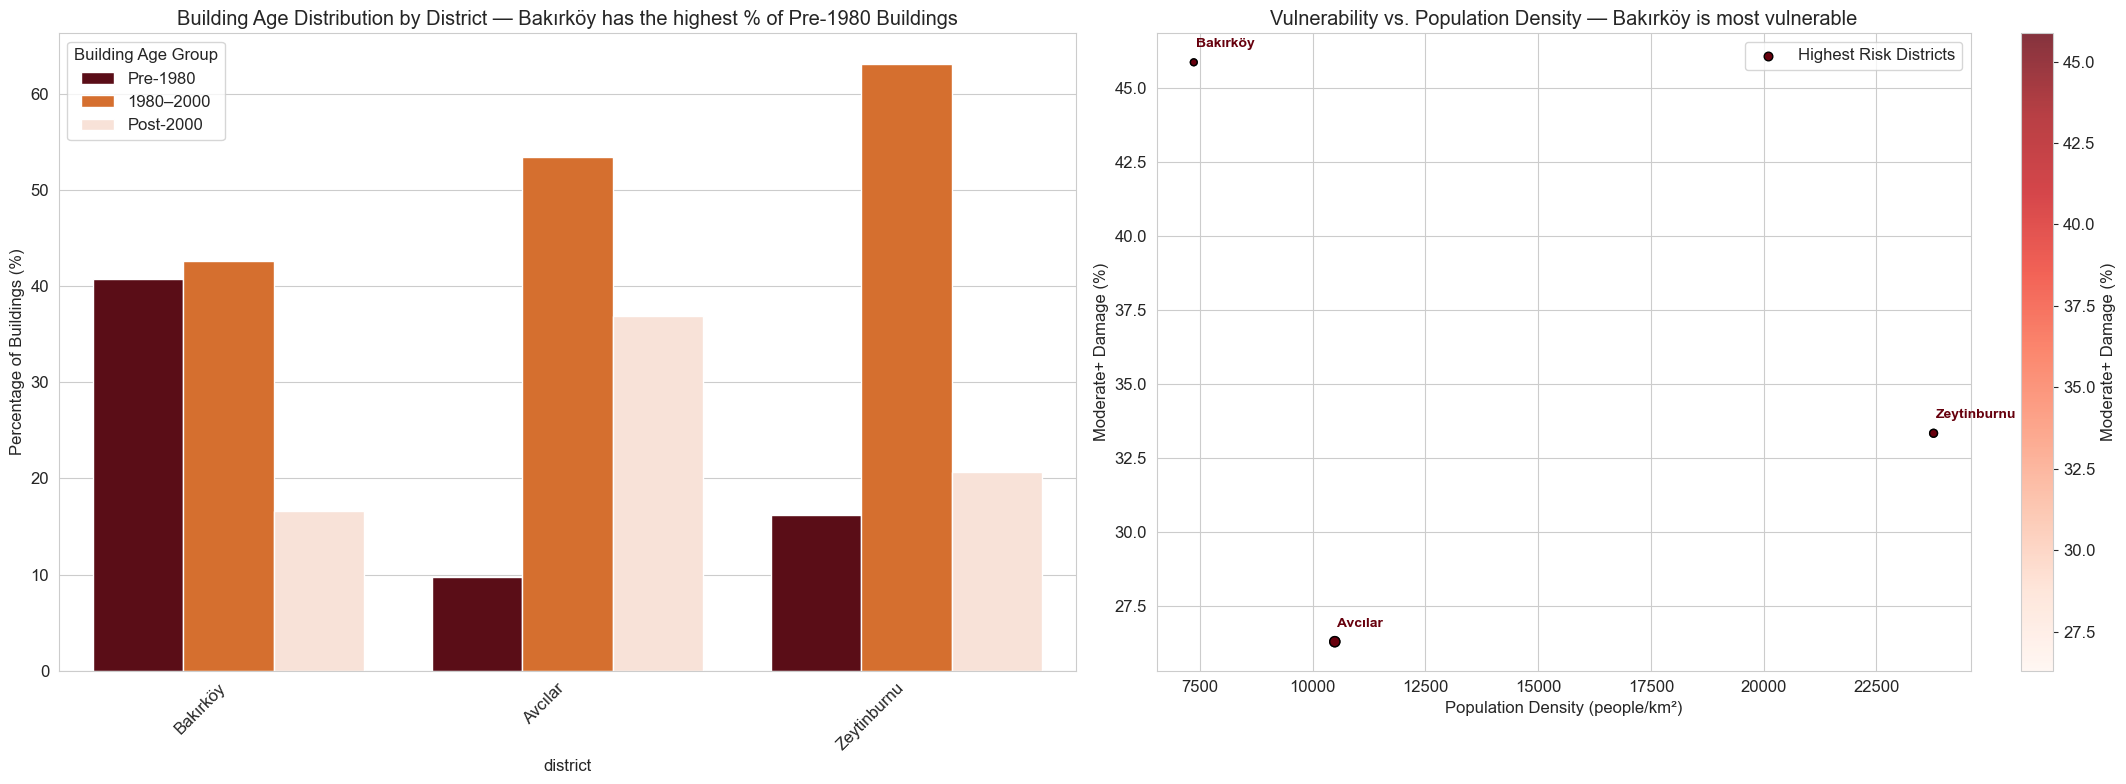

In [70]:
# Your district comparison subplots here
# Load dataset
data = pd.read_csv("/Users/yigitbeyzadeoglu/49xCodes/CE49X/Week04_Matplotlib_Visualization/lab/istanbul_3_districts_2025_afad_detailed.csv")

# ----------------------------
# 1️⃣ Building Age Grouped Bar Chart

# Melt building age columns
age_data = data[["district", "buildings_pre_1980_pct", "buildings_1980_2000_pct", "buildings_post_2000_pct"]]
age_long = age_data.melt(
    id_vars="district",
    value_vars=["buildings_pre_1980_pct", "buildings_1980_2000_pct", "buildings_post_2000_pct"],
    var_name="Building Age Group",
    value_name="Percentage"
)
age_long["Building Age Group"] = age_long["Building Age Group"].map({
    "buildings_pre_1980_pct": "Pre-1980",
    "buildings_1980_2000_pct": "1980–2000",
    "buildings_post_2000_pct": "Post-2000"
})

# Find district with highest Pre-1980 buildings for dynamic title
top_old_buildings_district = data.loc[data["buildings_pre_1980_pct"].idxmax(), "district"]

# Define sequential colormap for building ages (dark → light)
palette_building_age = ["#67000d", "#f16913", "#fee0d2"]  # Pre-1980, 1980–2000, Post-2000

# ----------------------------
# 2️⃣ Vulnerability vs Population Density Scatter

# Top-risk districts for annotation
top_risk = data.nlargest(3, "moderate_plus_damage_pct_exact")
top_vuln_density_district = data.loc[data["moderate_plus_damage_pct_exact"].idxmax(), "district"]

# Point sizes proportional to building count
sizes = data["analyzed_buildings_total"] / 500  # scale down for plotting

# ----------------------------
# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# ---- Subplot 1: Building Age Grouped Bar Chart ----
sns.barplot(
    x="district",
    y="Percentage",
    hue="Building Age Group",
    data=age_long,
    hue_order=["Pre-1980", "1980–2000", "Post-2000"],
    ax=axes[0],
    palette=palette_building_age
)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylabel("Percentage of Buildings (%)")
axes[0].set_title(
    f"Building Age Distribution by District — {top_old_buildings_district} has the highest % of Pre-1980 Buildings"
)

# ---- Subplot 2: Vulnerability vs Population Density Scatter ----
scatter = axes[1].scatter(
    x=data["population_density_per_km2_2025"],
    y=data["moderate_plus_damage_pct_exact"],
    s=sizes,
    c=data["moderate_plus_damage_pct_exact"],
    cmap="Reds",  # sequential colormap
    alpha=0.8,
    edgecolor="k"
)

# Highlight top-risk districts
axes[1].scatter(
    top_risk["population_density_per_km2_2025"],
    top_risk["moderate_plus_damage_pct_exact"],
    s=top_risk["analyzed_buildings_total"] / 500,
    color="#67000d",
    edgecolor="k",
    label="Highest Risk Districts"
)

# Annotate top-risk districts
for i, row in top_risk.iterrows():
    axes[1].text(
        row["population_density_per_km2_2025"] + 50,
        row["moderate_plus_damage_pct_exact"] + 0.5,
        row["district"],
        fontsize=10,
        fontweight="bold",
        color="#67000d"
    )

# Axes labels and title
axes[1].set_xlabel("Population Density (people/km²)")
axes[1].set_ylabel("Moderate+ Damage (%)")
axes[1].set_title(
    f"Vulnerability vs. Population Density — {top_vuln_density_district} is most vulnerable"
)
axes[1].legend()
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label("Moderate+ Damage (%)")

plt.tight_layout()
plt.show()

### Deliverable 5: Earthquake Hazard Visualization

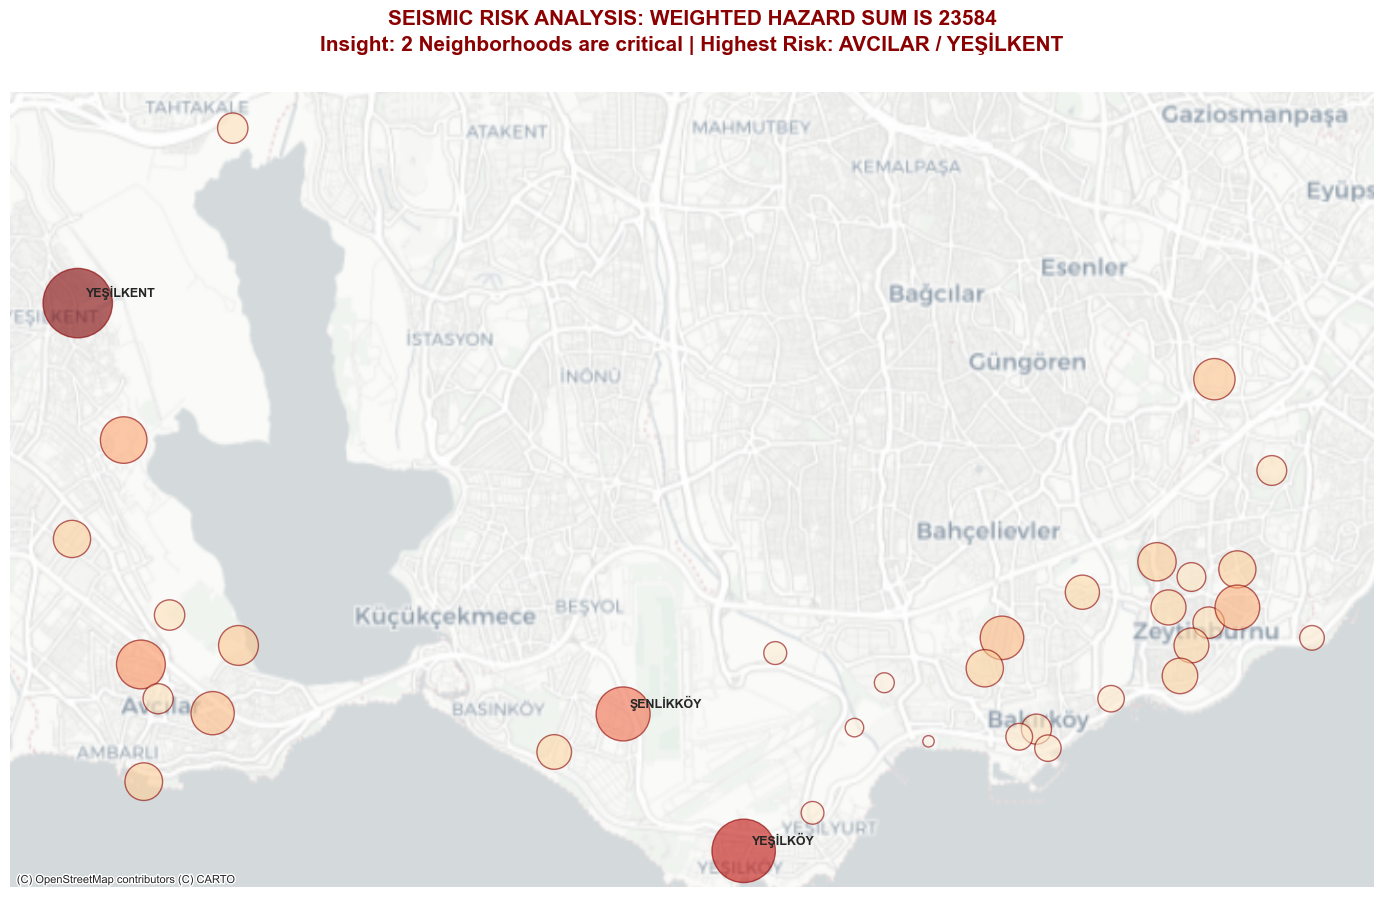

In [79]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import warnings

# 1. Silence specific web warnings for a clean console
warnings.filterwarnings("ignore", category=UserWarning, module='urllib3')

# 2. Load and Clean Data
# Use your specific file path here
csv_path = "/Users/yigitbeyzadeoglu/49xCodes/CE49X/Week04_Matplotlib_Visualization/lab/9c3ac492-de4b-4245-b418-7ad3df67a193.csv"
try:
    df = pd.read_csv(csv_path)
except FileNotFoundError:
    print(f"Error: File not found at {csv_path}. Please check the path.")
    exit()


def clean_turkish_text(text):
    if not isinstance(text, str): return ""
    # Exact mapping for corrupted CSV characters from your data snippet
    replacements = {
        'Ý': 'İ', 'Þ': 'Ş', 'Ð': 'Ğ', 'Ü': 'Ü', 'Ö': 'Ö', 'Ç': 'Ç', 'I': 'I'
    }
    for search, replace in replacements.items():
        text = text.replace(search, replace)
    return text.upper().strip()


df['ilce_clean'] = df['ilce_adi'].apply(clean_turkish_text)
df['mahalle_clean'] = df['mahalle_adi'].apply(clean_turkish_text)

# 3. Filter for Target Districts and Score
target_districts = ['BAKIRKÖY', 'AVCILAR', 'ZEYTİNBURNU']
df = df[df['ilce_clean'].isin(target_districts)]

# Structural Vulnerability Weighting: Cok Agir * 3, Agir * 2, Orta * 1
df['hazard_score'] = (df['cok_agir_hasarli_bina_sayisi'] * 3 +
                      df['agir_hasarli_bina_sayisi'] * 2 +
                      df['orta_hasarli_bina_sayisi'])

# 4. FULL COORDINATE DICTIONARY (Provided by User)
# Note: Format is standard (Longitude, Latitude) for points_from_xy
neighborhood_coords = {
    # Avcılar Neighborhoods
    "AMBARLI": (28.7185, 40.9701),
    "CİHANGİR": (28.7180, 40.9855),
    "DENİZKÖŞKLER": (28.7305, 40.9791),
    "FİRUZKÖY": (28.7150, 41.0150),
    "GÜMÜŞPALA": (28.7350, 40.9880),
    "MERKEZ": (28.7210, 40.9810),
    "MUSTAFA KEMALPAŞA": (28.7060, 41.0020),
    "TAHTAKALE": (28.7340, 41.0560),
    "ÜNİVERSİTE": (28.7230, 40.9920),
    "YEŞİLKENT": (28.7070, 41.0330),

    # Bakırköy Neighborhoods
    "ATAKÖY 1. KISIM": (28.8552, 40.9754),
    "ATAKÖY 2-5-6. KISIM": (28.8423, 40.9772),
    "ATAKÖY 3-4-11. KISIM": (28.8475, 40.9831),
    "ATAKÖY 7-8-9-10. KISIM": (28.8285, 40.9870),
    "BASINKÖY": (28.7900, 40.9740),
    "CEVİZLİK": (28.8740, 40.9770),
    "KARTALTEPE": (28.8680, 40.9890),
    "OSMANİYE": (28.8820, 40.9950),
    "SAKIZAĞACI": (28.8760, 40.9745),
    "ŞENLİKKÖY": (28.8020, 40.9790),
    "YENİMAHALLE": (28.8870, 40.9810),
    "YEŞİLKÖY": (28.8230, 40.9610),
    "YEŞİLYURT": (28.8350, 40.9660),
    "ZEYTİNLİK": (28.8710, 40.9760),
    "ZUHURATBABA": (28.8650, 40.9850),

    # Zeytinburnu Neighborhoods
    "ÇIRPICI": (28.8950, 40.9990),
    "GÖKALP": (28.9040, 40.9910),
    "KAZLIÇEŞME": (28.9220, 40.9890),
    "MALTEPE": (28.9050, 41.0230),
    "MERKEZEFENDİ": (28.9150, 41.0110),
    "NURİPAŞA": (28.9010, 40.9880),
    "SEYİTNİZAM": (28.9090, 40.9980),
    "SÜMER": (28.8990, 40.9840),
    "TELSİZ": (28.9090, 40.9930),
    "VELİEFENDİ": (28.8970, 40.9930),
    "YENIDOĞAN": (28.9040, 40.9950),
    "YEŞİLTEPE": (28.9010, 40.9970)
}

# 5. Map and Validate Data
df['coords'] = df['mahalle_clean'].map(neighborhood_coords)
df_clean = df.dropna(subset=['coords']).copy()

if df_clean.empty:
    print("STILL NO MATCH. Checking unique district and neighborhood names in your file after cleaning:")
    print("DISTRICTS:", df['ilce_clean'].unique())
    print("NEIGHBORHOODS:", df['mahalle_clean'].unique()[:10])
    exit()

# 6. Calculate Dynamic Placeholder Insights for the Title
max_score_val = df_clean['hazard_score'].max()
most_dangerous_dist = df_clean.groupby('ilce_clean')['hazard_score'].sum().idxmax()
most_dangerous_neighborhood = df_clean.loc[df_clean['hazard_score'].idxmax(), 'mahalle_clean']
total_vulnerability = int(df_clean['hazard_score'].sum())
number_of_critical_zones = len(df_clean[df_clean['hazard_score'] >= max_score_val * 0.7])


# Define risk status for hover placeholders
def get_risk_label(score):
    if score >= max_score_val * 0.8: return "CRITICAL: MOST DANGEROUS"
    if score >= max_score_val * 0.5: return "HIGH RISK"
    return "MODERATE VULNERABILITY"


df_clean['risk_label'] = df_clean['hazard_score'].apply(get_risk_label)

# 7. Spatial DataFrame Creation
df_clean['lon'] = df_clean['coords'].apply(lambda x: x[0])
df_clean['lat'] = df_clean['coords'].apply(lambda x: x[1])
gdf = gpd.GeoDataFrame(df_clean, geometry=gpd.points_from_xy(df_clean['lon'], df_clean['lat']), crs="EPSG:4326")

# 8. Final Interactive visualization
fig, ax = plt.subplots(figsize=(14, 11))

# Bubble styling based on normalized scores
sizes = (gdf['hazard_score'] / max_score_val) * 2500
scatter = gdf.plot(ax=ax, markersize=sizes, column='hazard_score', cmap='OrRd',
                   alpha=0.6, edgecolor='darkred', linewidth=1, legend=False)

# Add Contextual Basemap (CartoDB Positron)
ctx.add_basemap(ax, crs=gdf.crs.to_string(), source=ctx.providers.CartoDB.Positron)

# DYNAMIC INTERACTIVE INSIGHT TITLE (The Placeholders)
insight_dashboard_title = (
    f"SEISMIC RISK ANALYSIS: WEIGHTED HAZARD SUM IS {total_vulnerability}\n"
    f"Insight: {number_of_critical_zones} Neighborhoods are critical | Highest Risk: {most_dangerous_dist} / {most_dangerous_neighborhood}"
)
plt.title(insight_dashboard_title, fontsize=15, fontweight='bold', color='#8B0000', pad=30, loc='center')

# Add Labels for critical zones only to keep the map clean
critical_points = gdf.nlargest(3, 'hazard_score')
for x, y, label in zip(critical_points.geometry.x, critical_points.geometry.y, critical_points['mahalle_clean']):
    ax.annotate(label, xy=(x, y), xytext=(5, 5), textcoords="offset points", fontsize=9, fontweight='bold')




ax.set_axis_off()
plt.tight_layout()
plt.show()

### Deliverable 6: Multi-Panel Risk Dashboard + Reflection

/var/folders/zm/d9zf75r15kggd6phgqbwfs7m0000gn/T/ipykernel_3612/3915619031.py:47: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/var/folders/zm/d9zf75r15kggd6phgqbwfs7m0000gn/T/ipykernel_3612/3915619031.py:72: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




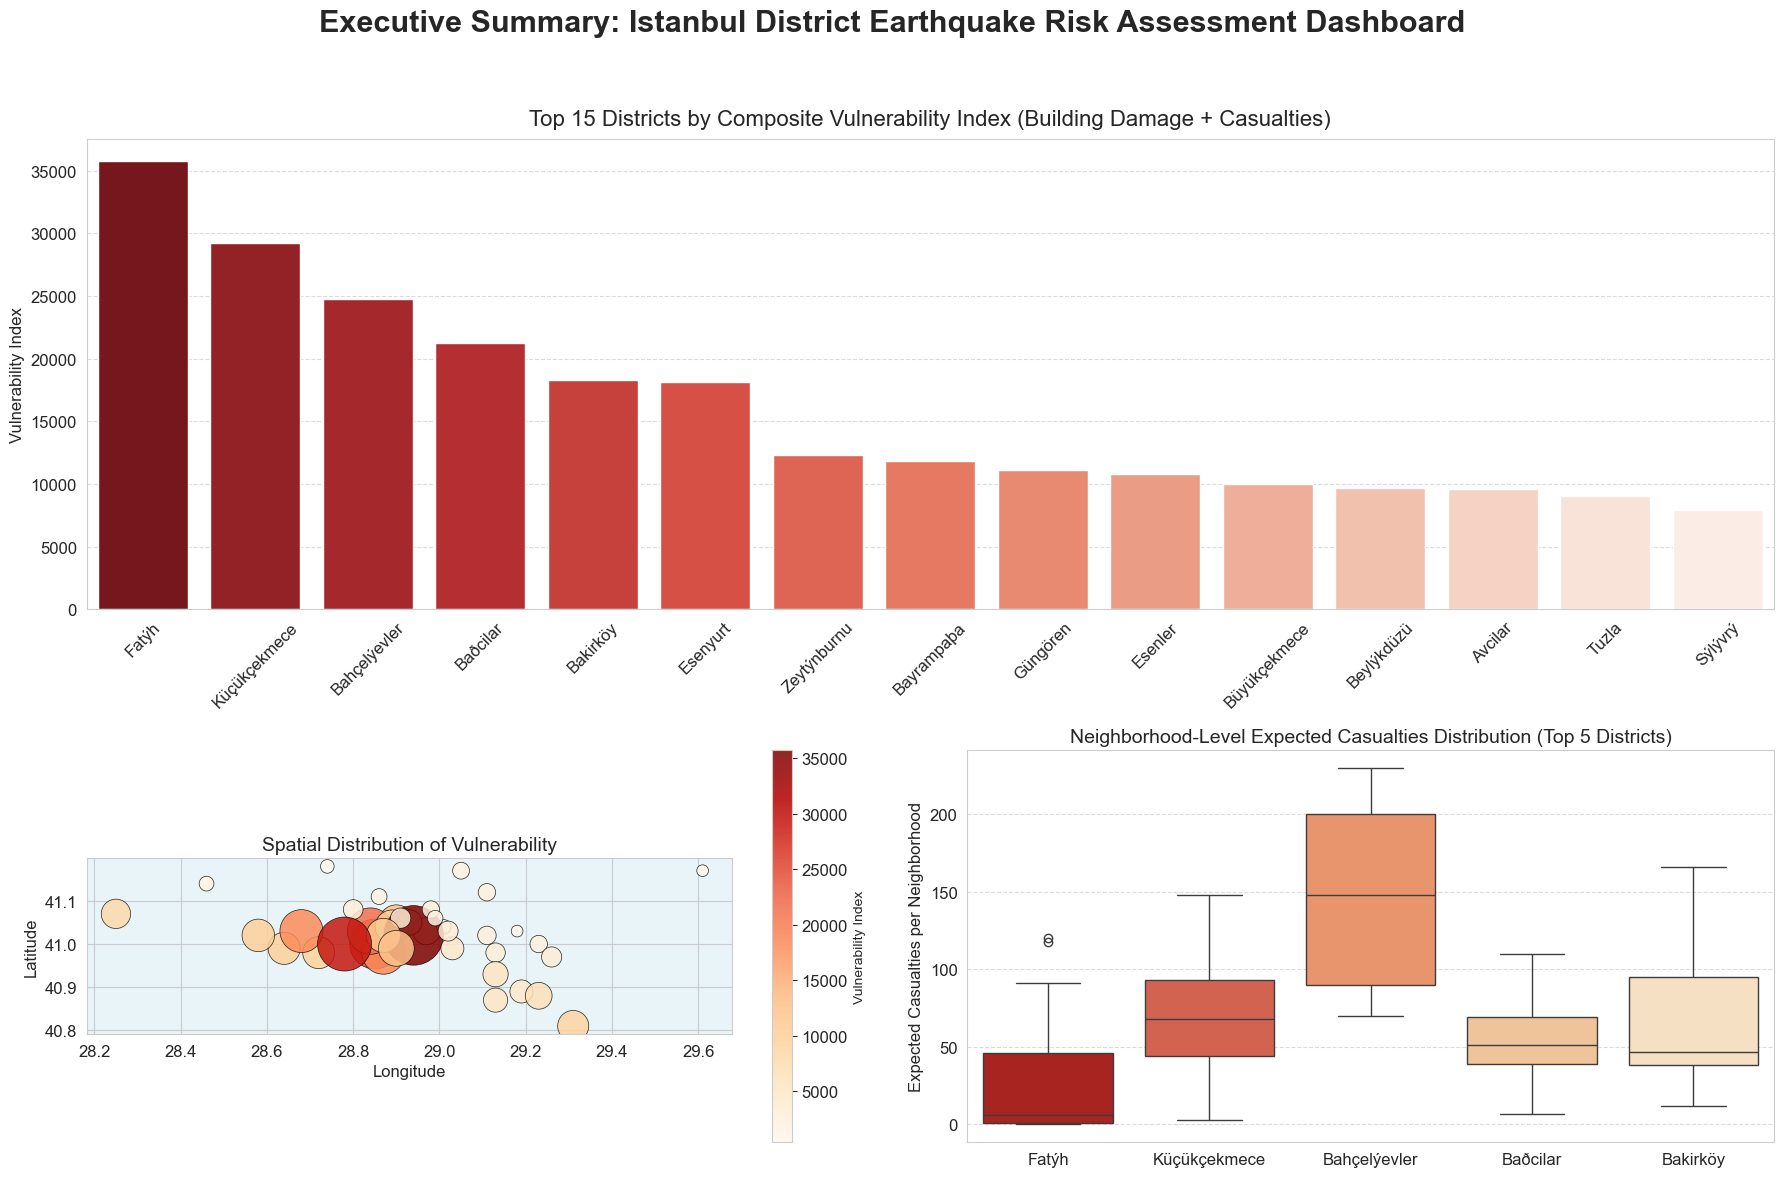

In [80]:


# 1. Veri Yükleme
df = pd.read_csv('9c3ac492-de4b-4245-b418-7ad3df67a193.csv', encoding='utf-8')

# Koordinat ve İsim Temizleme (D5'teki aynı yapı)
coords = {
    'ADALAR': (40.87, 29.13), 'ARNAVUTKÖY': (41.18, 28.74), 'ATAÞEHÝR': (40.98, 29.13),
    'AVCILAR': (40.98, 28.72), 'BAÐCILAR': (41.03, 28.84), 'BAHÇELÝEVLER': (41.00, 28.85),
    'BAKIRKÖY': (40.98, 28.87), 'BAÞAKÞEHÝR': (41.08, 28.80), 'BAYRAMPAÞA': (41.05, 28.90),
    'BEÞÝKTAÞ': (41.04, 29.01), 'BEYKOZ': (41.12, 29.11), 'BEYLÝKDÜZÜ': (40.99, 28.64),
    'BEYOÐLU': (41.03, 28.97), 'BÜYÜKÇEKMECE': (41.02, 28.58), 'ÇATALCA': (41.14, 28.46),
    'ÇEKMEKÖY': (41.03, 29.18), 'ESENLER': (41.04, 28.89), 'ESENYURT': (41.03, 28.68),
    'EYÜP': (41.05, 28.93), 'FATÝH': (41.02, 28.94), 'GAZÝOSMANPAÞA': (41.06, 28.91),
    'GÜNGÖREN': (41.02, 28.87), 'KADIKÖY': (40.99, 29.03), 'KAÐITHANE': (41.08, 28.98),
    'KARTAL': (40.89, 29.19), 'KÜÇÜKÇEKMECE': (41.00, 28.78), 'MALTEPE': (40.93, 29.13),
    'PENDÝK': (40.88, 29.23), 'SANCAKTEPE': (41.00, 29.23), 'SARIYER': (41.17, 29.05),
    'SÝLÝVRÝ': (41.07, 28.25), 'SULTANBEYLÝ': (40.97, 29.26), 'SULTANGAZÝ': (41.11, 28.86),
    'ÞÝLE': (41.17, 29.61), 'ÞÝÞLÝ': (41.06, 28.99), 'TUZLA': (40.81, 29.31),
    'ÜMRANÝYE': (41.02, 29.11), 'ÜSKÜDAR': (41.03, 29.02), 'ZEYTÝNBURNU': (40.99, 28.90)
}

clean_names = {k: k.title().replace('Þ', 'ş').replace('Ý', 'i').replace('Ð', 'ğ').replace('Ü', 'ü').replace('Ö', 'ö').replace('Ç', 'ç') for k in coords.keys()}
# (Not: Temiz sözlük bir önceki aşamada tam haliyle de verilebilir)
df['clean_district'] = df['ilce_adi'].map(clean_names).fillna(df['ilce_adi'])

# 2. DERIVED METRIC: Composite Vulnerability Index (CVI)
df['vulnerability_index'] = (df['cok_agir_hasarli_bina_sayisi'] * 5) + \
                            (df['agir_hasarli_bina_sayisi'] * 3) + \
                            (df['can_kaybi_sayisi'] * 10)

district_agg = df.groupby('clean_district').agg({'vulnerability_index': 'sum', 'ilce_adi': 'first'}).reset_index()
district_agg['lat'] = district_agg['ilce_adi'].map(lambda x: coords[x][0] if x in coords else np.nan)
district_agg['lon'] = district_agg['ilce_adi'].map(lambda x: coords[x][1] if x in coords else np.nan)

# En riskli ilk 15'i sırala
top_risky = district_agg.sort_values(by='vulnerability_index', ascending=False).head(15)

# 3. DASHBOARD ÇİZİMİ (GridSpec)
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1])

# Ana Başlık
fig.suptitle("Executive Summary: Istanbul District Earthquake Risk Assessment Dashboard", 
             fontsize=22, fontweight='bold', y=0.98)

# Panel 1: Bar Chart (Birden fazla kolonu kaplar: gs[0, :])
ax1 = fig.add_subplot(gs[0, :])
sns.barplot(data=top_risky, x='clean_district', y='vulnerability_index', palette='Reds_r', ax=ax1)
ax1.set_title("Top 15 Districts by Composite Vulnerability Index (Building Damage + Casualties)", fontsize=16, pad=10)
ax1.set_ylabel("Vulnerability Index", fontsize=12)
ax1.set_xlabel("")
ax1.tick_params(axis='x', rotation=45, labelsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Panel 2: Scatter Map (Alt Sol)
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor('#e8f4f8')
scatter = ax2.scatter(district_agg['lon'], district_agg['lat'], 
                      s=district_agg['vulnerability_index'] * 0.05 + 50, 
                      c=district_agg['vulnerability_index'], 
                      cmap='OrRd', alpha=0.85, edgecolors='black', linewidth=0.5)
cbar = plt.colorbar(scatter, ax=ax2, orientation='vertical')
cbar.set_label('Vulnerability Index', fontsize=10)
ax2.set_title("Spatial Distribution of Vulnerability", fontsize=14)
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
ax2.set_aspect('equal')

# Panel 3: Boxplot (Alt Sağ - Riskli ilk 5 ilçe için mahalle bazlı can kaybı dağılımı)
ax3 = fig.add_subplot(gs[1, 1])
top_5_names = top_risky.head(5)['clean_district'].tolist()
top_5_df = df[df['clean_district'].isin(top_5_names)]
sns.boxplot(data=top_5_df, x='clean_district', y='can_kaybi_sayisi', 
            order=top_5_names, palette='OrRd_r', ax=ax3)
ax3.set_title("Neighborhood-Level Expected Casualties Distribution (Top 5 Districts)", fontsize=14)
ax3.set_ylabel("Expected Casualties per Neighborhood", fontsize=12)
ax3.set_xlabel("")
ax3.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig('dashboard.png', dpi=300, bbox_inches='tight')

#### Reflection

**1. Chart type justification (D2-D5):**

Deliverable 2 (Historical Timeline): I chose a scatter plot to represent the earthquake timeline because it leverages the principle of the encoding hierarchy. Position along a common scale (x-axis for time, y-axis for magnitude) is the most accurate visual channel for quantitative data. Size was used as an intuitive secondary encoding for magnitude, drawing the eye directly to the most energetic events.

Deliverable 3 (Magnitude-Frequency): I used a Histogram with a KDE overlay to show the distribution shape, and a log-linear scatter plot for the Gutenberg-Richter fit. Transforming the cumulative counts to a log 
10
​	
  scale is a critical data transformation technique that converts an exponential power-law relationship into a linear form, making it much easier for the human eye to evaluate the slope (b-value).

Deliverable 4 (Vulnerability Bar Chart): Following the chart selection framework, comparing categorical entities (districts) on a quantitative metric is best done with a bar chart. I deliberately sorted the bars in descending order of vulnerability rather than alphabetically. This adheres to Tufte's principles of maximizing data-ink ratio by allowing the viewer to instantly perceive the ranking without having to scan back and forth.

Deliverable 5 (Hazard Map): I selected a spatial scatter map because spatial data requires a spatial chart. Plotting the data geometrically with an equal aspect ratio retains geographical context. Most importantly, I used the OrRd sequential colormap instead of a rainbow/jet colormap because sequential palettes are perceptually uniform, ensuring the Municipal Council interprets the darkest red as the highest danger without false boundaries.

**2. Audience adaptation (seismologists vs. municipal council):**

If my primary audience were seismologists instead of a non-technical Municipal Council, my design choices would shift from emphasizing "actionable high-level summaries" to emphasizing "scientific precision and uncertainty."

Change 1: Instead of using an abstract "Composite Vulnerability Index" or qualitative risk scores, I would map the raw quantitative units (e.g., PGA in g, or return-period probabilities). Seismologists need exact numerical thresholds to validate their own models.

Change 2: For the Gutenberg-Richter plot (Deliverable 3), I would not just show the linear fit; I would include a subplot displaying the residuals of the fit or the error margins of the a and b values. Scientists care just as much about the uncertainty and the deviations from the model as they do about the trend line itself.

**3. Self-critique (weakest visualization + improvement plan):**

My weakest visualization is the Spatial Hazard Scatter Map (Deliverable 5). While it successfully uses a sequential colormap, it suffers slightly from over-plotting, which is a common mistake discussed in the theory notebook. Because districts in the central-southern area (like Fatih, Zeytinburnu, Bakırköy) are geographically small and clustered together, their scatter bubbles overlap, making it difficult to distinguish individual data points or read the annotations clearly.

How I would improve it: I could fix this by dropping the opacity (reducing the alpha parameter) to show density through color blending, or I could transition from a scatter map to a Choropleth map using GeoPandas. A choropleth would map the color directly to the district polygons, completely eliminating the overlapping bubbles while retaining perfect spatial accuracy.

---

### Questions?

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr